In [1]:
import minigrid
import numpy as np
import gymnasium as gym
import causal_gym as cgym
import matplotlib.pyplot as plt

from causal_gym.envs import WindyMiniGridPCH
from causal_gym.core.wrappers import MiniGridActionRemapWrapper
from causal_gym.envs import WIND_DIST

In [ ]:
SEED = 6458

def show_obs(img, name=None):
    plt.imshow(img)
    plt.axis('off')
    if name is not None:
        plt.tight_layout()
        fig = plt.gcf()
        fig.set_size_inches(8, 6)
        imgPath = f'env-{name}.png'
        fig.savefig(imgPath, dpi=800, bbox_inches='tight', pad_inches=0)
    plt.show()

### Empty World

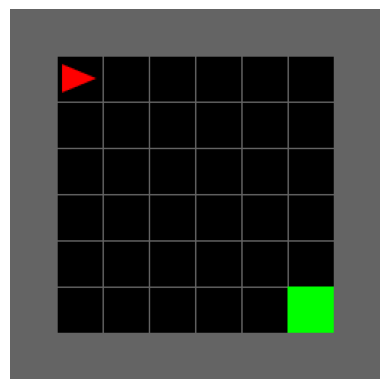

In [3]:
env = gym.make('MiniGrid-Empty-8x8-v0', max_episode_steps=70, agent_pov=False, render_mode='rgb_array', highlight=False)
_, info = env.reset(seed=SEED)
show_obs(env.render())

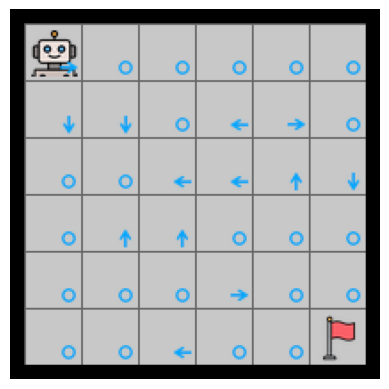

In [4]:
windy_env = MiniGridActionRemapWrapper(WindyMiniGridPCH(env=env, show_wind=True))
windy_env.reset(seed=SEED)
show_obs(windy_env.render())

Actions.right -0.1


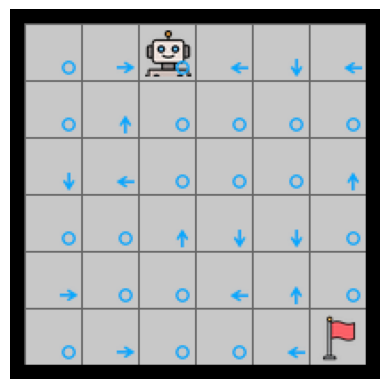

In [5]:
a, sp, r, term, trun, info = windy_env.see(bpolicy=lambda state, wind: 3)
print(a, r)
show_obs(windy_env.render())

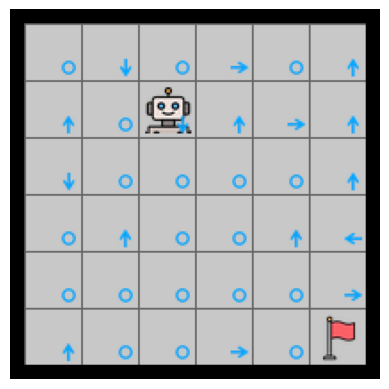

In [6]:
windy_env.agent_pos = (3,2)
windy_env.agent_dir = 2
windy_env.wind_dir = 1
show_obs(windy_env.render())

### LavaCross

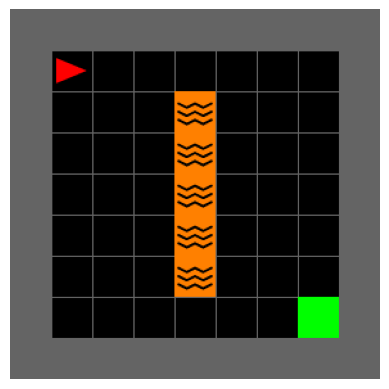

In [7]:
env = gym.make('Custom-LavaCrossing-easy-v0', max_episode_steps=70, agent_pov=False, render_mode='rgb_array', highlight=False, size=9)
_, info = env.reset(seed=SEED)
show_obs(env.render())

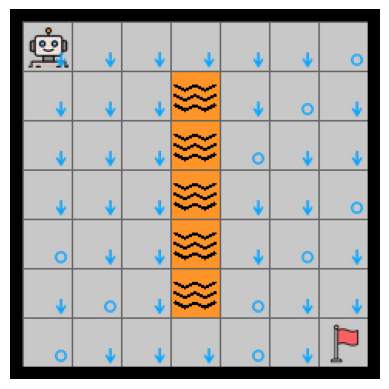

In [8]:
windy_env = MiniGridActionRemapWrapper(WindyMiniGridPCH(env=env, show_wind=True, wind_dist=WIND_DIST['Custom-LavaCrossing-easy-v0']))
init_obs, info = windy_env.reset(seed=SEED)
show_obs(windy_env.render())

Actions.down -0.1 False False


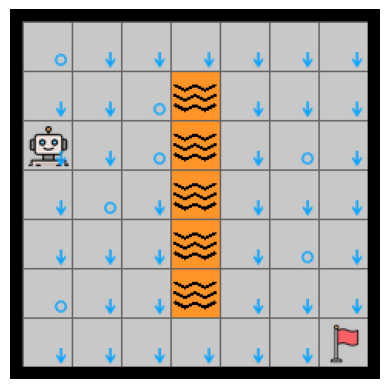

In [9]:
a, sp, r, term, trun, info = windy_env.see(bpolicy=lambda state, wind: 1)
print(a, r, term, trun)
show_obs(windy_env.render())

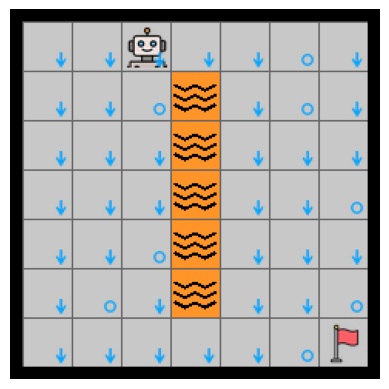

In [10]:
# a, sp, r, term, trun, info = windy_env.see(bpolicy=lambda state, wind: 1)
# print(a, r, term, trun)
# (3, 1) 3 -0.1 (4, 1) 0 0
# (3, 1) 3 -0.1 (4, 1) 1 0.8
# (3, 1) 3 -0.1 (3, 1) 2 0
# (3, 1) 3 -0.1 (4, 1) 3 0
# (3, 1) 3 -0.1 (4, 1) 4 0.2
windy_env.agent_pos = (3,1)
windy_env.agent_dir = 0
windy_env.wind_dir = 1
show_obs(windy_env.render())

(4, 2) -1.1


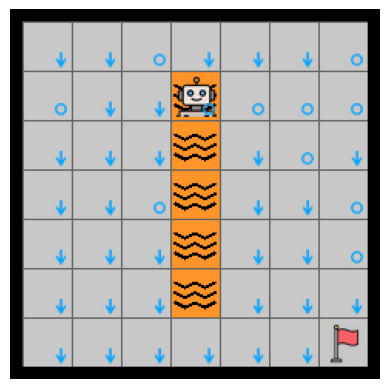

In [11]:
sp, r, _, _, _ = windy_env.do(3)
print(sp, r)
show_obs(windy_env.render())

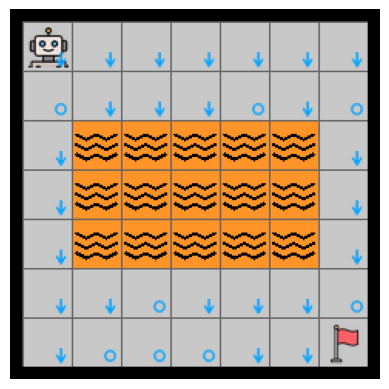

In [12]:
env = gym.make('Custom-LavaCrossing-hard-v0', max_episode_steps=70, agent_pov=False, render_mode='rgb_array', highlight=False, size=9)
_, info = env.reset(seed=SEED)
windy_env = MiniGridActionRemapWrapper(WindyMiniGridPCH(env=env, show_wind=True, wind_dist=WIND_DIST['Custom-LavaCrossing-hard-v0']))
init_obs, info = windy_env.reset(seed=SEED)
show_obs(windy_env.render())

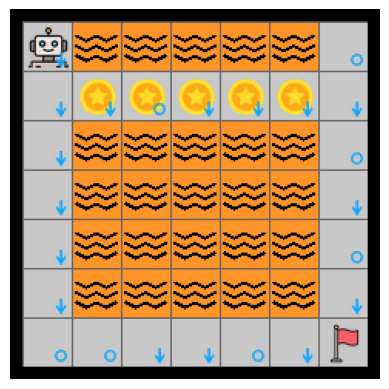

In [13]:
env = gym.make('Custom-LavaCrossing-extreme-v0', max_episode_steps=70, agent_pov=False, render_mode='rgb_array', highlight=False, size=9)
_, info = env.reset(seed=SEED)
windy_env = MiniGridActionRemapWrapper(WindyMiniGridPCH(env=env, show_wind=True, wind_dist=WIND_DIST['Custom-LavaCrossing-extreme-v0']))
init_obs, info = windy_env.reset(seed=SEED)
show_obs(windy_env.render())

(1, 3) -0.1


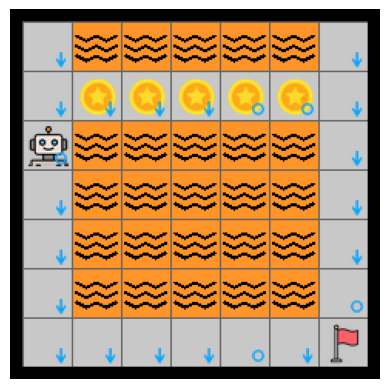

In [14]:
sp, r, _, _, _ = windy_env.do(1)
print(sp, r)
show_obs(windy_env.render())

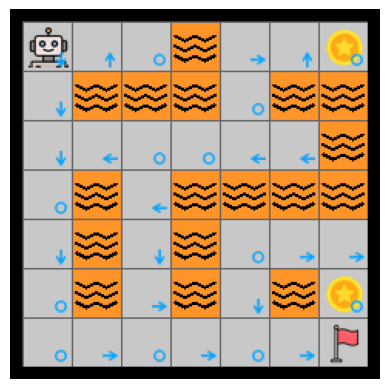

In [15]:
env = gym.make('Custom-LavaCrossing-maze-v0', max_episode_steps=70, agent_pov=False, render_mode='rgb_array', highlight=False, size=9)
_, info = env.reset(seed=SEED)
windy_env = MiniGridActionRemapWrapper(WindyMiniGridPCH(env=env, show_wind=True, wind_dist=WIND_DIST['Custom-LavaCrossing-maze-v0']))
init_obs, info = windy_env.reset(seed=SEED)
show_obs(windy_env.render())

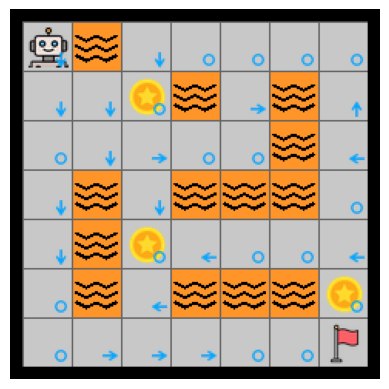

In [16]:
env = gym.make('Custom-LavaCrossing-maze-complex-v0', max_episode_steps=70, agent_pov=False, render_mode='rgb_array', highlight=False, size=9)
_, info = env.reset(seed=SEED)
windy_env = MiniGridActionRemapWrapper(WindyMiniGridPCH(env=env, show_wind=True, wind_dist=WIND_DIST['Custom-LavaCrossing-maze-v0']))
init_obs, info = windy_env.reset(seed=SEED)
show_obs(windy_env.render())

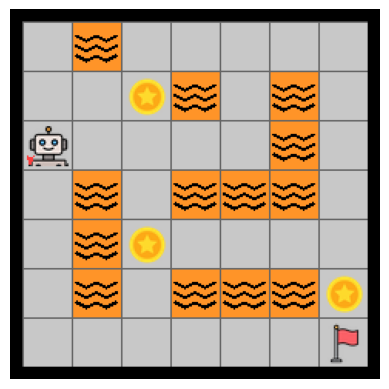

In [ ]:
windy_env.do(1)
show_obs(windy_env.render(action_todo=1, show_policy=True, show_wind=False))

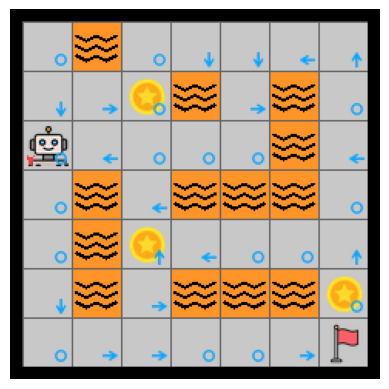

In [25]:
show_obs(windy_env.render(action_todo=1, show_policy=True, show_wind=True))

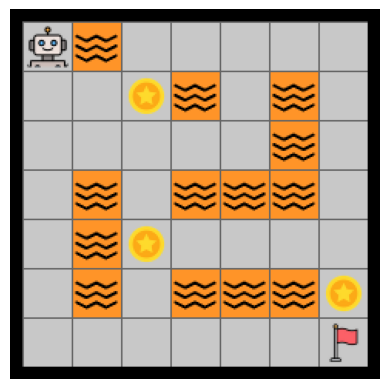

In [ ]:
show_obs(windy_env.render_map(mappings={s:1 for s in np.ndindex(*windy_env.state_space)}))

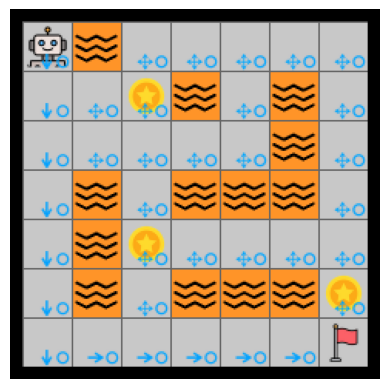

In [20]:
show_obs(windy_env.render_map(mappings={s:1 for s in np.ndindex(*windy_env.state_space)}, draw_wind=True))

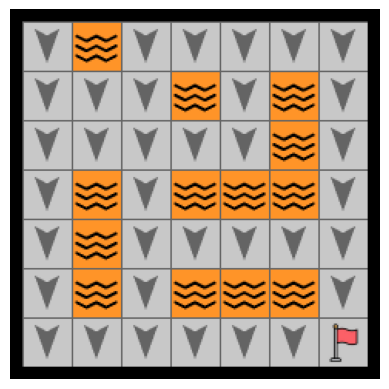

In [22]:
show_obs(windy_env.render_map(mappings={s:1 for s in np.ndindex(*windy_env.state_space)}, draw_wind=False, draw_policy=True))

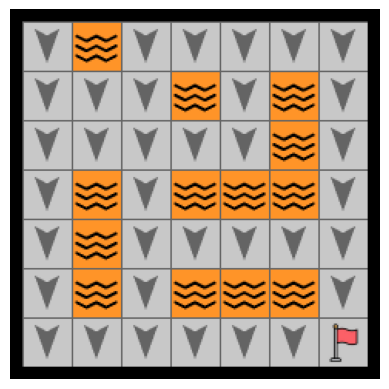

In [ ]:
show_obs(windy_env.render_map(mappings={s:1 for s in np.ndindex(*windy_env.state_space)}, draw_wind=True, draw_policy=True))